# 0. Stock Direction Classifier

In [25]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

In [26]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Data Collection

## 1.1 Download data

In [27]:
ticker = "AAPL"

df = yf.download(ticker, start="2010-01-01", end="2024-01-01")

df = df[["Close"]] # We'll only keep the 'Close' column
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,AAPL
Date,
2010-01-04,6.406481
2010-01-05,6.417557
2010-01-06,6.315478
2010-01-07,6.303801
2010-01-08,6.345710


## 1.2 Plot closing prices

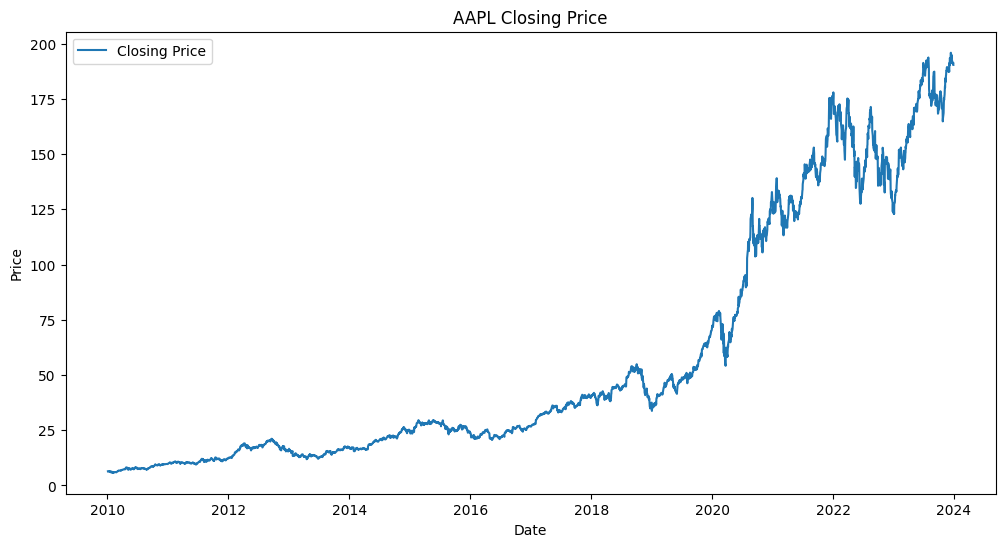

In [28]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["Close"], label="Closing Price")
plt.title(f"{ticker} Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

# 2. Feature Engineering

## 2.1 Log returns

In [29]:
df["log_return"] = np.log(df["Close"] / df["Close"].shift(1)) # Calculate log returns

## 2.2 Technical features

In [30]:
# Moving averages
df["ma_5_ratio"] = df["Close"] / df["Close"].rolling(5).mean()
df["ma_20_ratio"] = df["Close"] / df["Close"].rolling(20).mean()

# Volatility
df["volatility_5"] = df["log_return"].rolling(5).std()
df["volatility_20"] = df["log_return"].rolling(20).std()

# Momentum
df["momentum_5"] = df["log_return"].rolling(5).sum()
df["momentum_20"] = df["log_return"].rolling(20).sum()

# Relative Strength Index (RSI)
def compute_rsi(series, window=14):
    delta = series.diff()
    gain = delta.clip(lower=0).rolling(window).mean()
    loss = (-delta.clip(upper=0)).rolling(window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df["rsi"] = compute_rsi(df["Close"])

## 2.3 Target

In [31]:
df["target"] = (df["log_return"].shift(-1) > 0).astype(int) # We will later drop the last row which will have NaN target

In [32]:
count = (df["target"] > 0).sum()
baseline_accuracy = count / len(df) * 100
print(f"Baseline accuracy (predict always 'up'): {baseline_accuracy:.2f}%") # Starting accuracy. Can we beat it?

Baseline accuracy (predict always 'up'): 52.87%


# 3. Getting the data ready

## 3.1 X and y

In [33]:
features = ["log_return", "ma_5_ratio", "ma_20_ratio", "volatility_5", "volatility_20", "momentum_5", "momentum_20", "rsi"]

df_clean = df[features + ["target"]].dropna() # Drop rows with NaN values resulting from rolling calculations
X = df_clean[features]
y = df_clean["target"]

## 3.2 Splitting the data

In [34]:
train_split = (int(len(X) * 0.7))
val_split = (int(len(X) * 0.2))

X_train, y_train = X[:train_split], y[:train_split]
X_val, y_val = X[train_split:train_split+val_split], y[train_split:train_split+val_split]
X_test, y_test = X[train_split+val_split:], y[train_split+val_split:]

len(X_train), len(X_val), len(X_test)

(2451, 700, 351)

## 3.3 Scaling the data

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

## 3.4 Converting data to tensors and sending them to the device

In [36]:
X_train_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).to(device)

## 3.5 Setup DataLoader

In [37]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor) # TensorDataset combines features and labels into a single dataset object
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=32)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)


# 4. Build and instantiate a baseline model

## 4.1 Baseline Model Architecture

In [38]:
from torch import nn

class StockDirectionModel(nn.Module):
    def __init__(self, input_features: int = 8, hidden_units: int = 16, output_features: int = 1):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(in_features=hidden_units, out_features=output_features)
        )

    def forward(self, x):
            return self.linear_layer_stack(x)
        
model = StockDirectionModel(input_features=8,
                            hidden_units=16,
                            output_features=1).to(device)

# 5. Training Loop

## 5.1 Choose a loss function and optimizer

In [39]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(),
                             lr=0.001)

## 5.2 Setup an accuracy function

In [40]:
def accuracy_fn(y_pred, y_true):
    predicted_classes = (y_pred > 0).float()  # logit > 0 = sigmoid > 0.5
    correct = (predicted_classes == y_true).sum().item()
    return correct / len(y_true) * 100

## 5.3 Train and evaluate the model

In [ ]:
torch.manual_seed(42)

epochs = 50

# These lists will store the loss and accuracy values for each epoch, which we can later use for visualization.
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    print(f"Epoch: {epoch}------")
    model.train()
    train_loss, train_acc = 0, 0
    val_loss, val_acc = 0, 0
    for batch, (X_batch, y_batch) in enumerate(train_loader):

        y_pred = model(X_batch).squeeze()
        loss = loss_fn(y_pred, y_batch)
        train_loss += loss.item()
        train_acc += accuracy_fn(y_pred, y_batch.long())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Validation loop
    model.eval()
    val_loss = 0
    with torch.inference_mode():
        for batch, (X_batch, y_batch) in enumerate(val_loader):
            y_pred = model(X_batch).squeeze()

            loss = loss_fn(y_pred, y_batch)
            val_loss += loss.item()
            val_acc += accuracy_fn(y_pred, y_batch.long())

    train_losses.append(train_loss / len(train_loader))
    val_losses.append(val_loss / len(val_loader))
    train_accs.append(train_acc / len(train_loader))
    val_accs.append(val_acc / len(val_loader))

    print(f"Epoch {epoch} | "
          f"Train loss: {train_losses[-1]:.4f} | "
          f"Train acc: {train_accs[-1]:.2f}% | "
          f"Val loss: {val_losses[-1]:.4f} | "
          f"Val acc: {val_accs[-1]:.2f}%")

Epoch: 0------
Epoch 0 | Train loss: 0.7041 | Train acc: 48.22% | Val loss: 0.6944 | Val acc: 49.72%
Epoch: 1------
Epoch 1 | Train loss: 0.6957 | Train acc: 52.48% | Val loss: 0.6940 | Val acc: 51.44%
Epoch: 2------
Epoch 2 | Train loss: 0.6919 | Train acc: 52.28% | Val loss: 0.6955 | Val acc: 51.72%
Epoch: 3------
Epoch 3 | Train loss: 0.6955 | Train acc: 48.68% | Val loss: 0.6950 | Val acc: 52.46%
Epoch: 4------
Epoch 4 | Train loss: 0.6926 | Train acc: 52.62% | Val loss: 0.6948 | Val acc: 52.03%
Epoch: 5------
Epoch 5 | Train loss: 0.6925 | Train acc: 50.79% | Val loss: 0.6936 | Val acc: 52.17%
Epoch: 6------
Epoch 6 | Train loss: 0.6912 | Train acc: 51.82% | Val loss: 0.6932 | Val acc: 53.17%
Epoch: 7------
Epoch 7 | Train loss: 0.6912 | Train acc: 52.71% | Val loss: 0.6932 | Val acc: 53.45%
Epoch: 8------
Epoch 8 | Train loss: 0.6906 | Train acc: 53.92% | Val loss: 0.6933 | Val acc: 53.59%
Epoch: 9------
Epoch 9 | Train loss: 0.6903 | Train acc: 52.73% | Val loss: 0.6933 | Val ac

# 6. Testing Loop

## 6.1 Let's test the model

In [42]:
model.eval()
test_loss, test_acc = 0, 0
with torch.inference_mode():
    for batch, (X_batch, y_batch) in enumerate(test_loader):
        y_pred = model(X_batch).squeeze()
        loss = loss_fn(y_pred, y_batch)
        test_loss += loss.item()
        test_acc += accuracy_fn(y_pred, y_batch.long())

print(f"Test loss: {test_loss/len(test_loader):.4f} | "
      f"Test acc: {test_acc/len(test_loader):.2f}%")

# Note: accuracy_fn averages per-batch accuracies (unweighted by batch size),
# so this may slightly differ from sklearn overall accuracy on the last partial batch.

Test loss: 0.7014 | Test acc: 49.03%


## 6.2 Confusion Matrix

              precision    recall  f1-score   support

        Down       0.42      0.19      0.26       167
          Up       0.51      0.76      0.61       184

    accuracy                           0.49       351
   macro avg       0.47      0.48      0.44       351
weighted avg       0.47      0.49      0.45       351



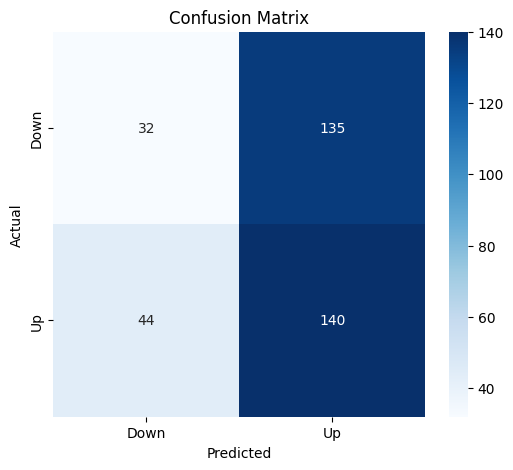

In [43]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

all_preds, all_labels = [], []

model.eval()
with torch.inference_mode():
    for X_batch, y_batch in test_loader:
        predicted = (model(X_batch).squeeze() > 0).long()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=["Down", "Up"]))

# Confusion matrix visual
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Down", "Up"],
            yticklabels=["Down", "Up"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()



The confusion matrix reveals a clear **positive class bias**: the model overwhelmingly predicts "Up", achieving a recall of 78% for upward movements but only 18% for downward ones. In other words, it correctly identifies roughly 3 out of 4 rising days, but misses more than 4 out of 5 falling days. This imbalance means the model has learned little more than a "default to Up" heuristic — which, given that AAPL closed higher on ~53% of days, is arguably the path of least resistance. Overall accuracy sits around ~50%, barely matching random guessing and well below the naive baseline (52.87%).

# 7. Baseline Model Conclusions

## 7.1 Accuracy and loss graphs

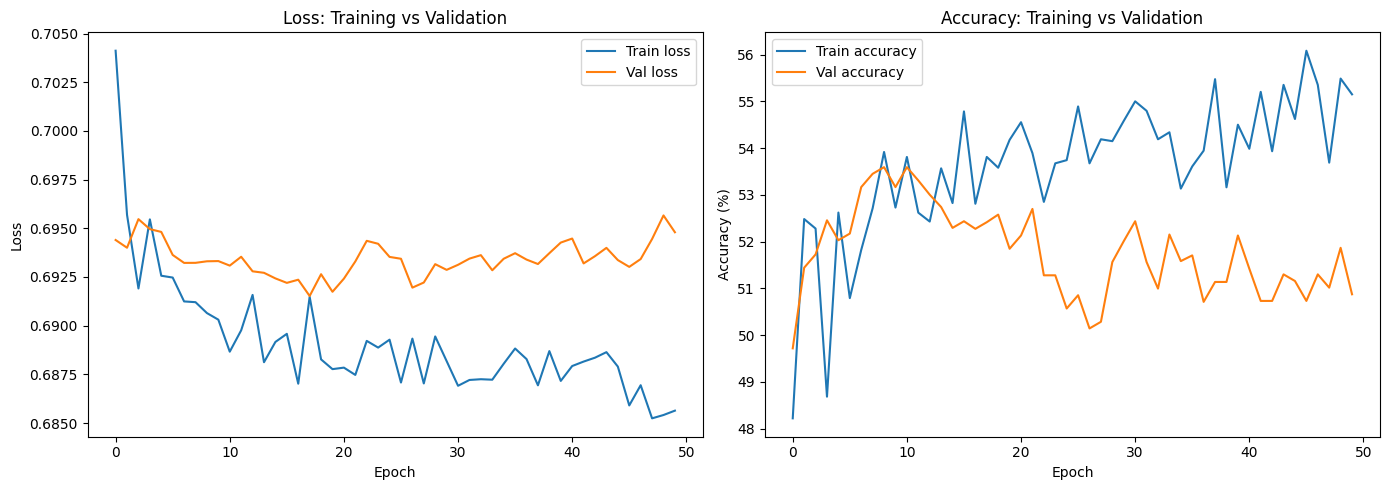

In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Grafico loss
ax1.plot(train_losses, label="Train loss")
ax1.plot(val_losses, label="Val loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss: Training vs Validation")
ax1.legend()

# Grafico accuracy
ax2.plot(train_accs, label="Train accuracy")
ax2.plot(val_accs, label="Val accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Accuracy: Training vs Validation")
ax2.legend()

plt.tight_layout()
plt.show()

## 7.2 Takeaway

I'm afraid that, if the model would have been able to predict the stock market in the slightest, I would not have been here posting this project.
However, on a positive note, this is pretty much in line with the **Efficient Market Hypothesis**!

The model achieves a test accuracy of ~50%, roughly matching random guessing and still below the naive baseline of always predicting "Up" (52.87%). The confusion matrix makes the failure mode explicit: the model developed a strong **upward bias**, predicting "Up" on most days. This is consistent with several issues:

- **Noisy data**: daily stock returns are influenced by millions of factors (news, geopolitics, macroeconomic events, investor sentiment) that 8 technical indicators simply cannot capture.

- **Efficient Market Hypothesis**: according to the EMH, stock prices already reflect all available public information. If patterns from moving averages and RSI were truly predictive, traders would exploit them until they disappear.

- **Overfitting vs generalization**: during training we can observe that the validation loss starts diverging from the training loss after just a few epochs. This confirms that the model struggles to find real patterns and tends to memorize noise when trained for too long.

- **Class imbalance effect**: with AAPL closing higher ~53% of days, the model found the easiest solution — predict "Up" by default — rather than learning genuinely discriminative features.

# 8. Hyperparameter Tuning

The baseline model used fairly arbitrary defaults. Here we systematically vary four key hyperparameters (hidden layer size, learning rate, dropout rate, and batch size) to see whether any configuration meaningfully improves accuracy.

## 8.1 Experiment model

In [ ]:
def run_experiment(hidden_units=16, lr=0.001, dropout=0.3, batch_size=32, epochs=50, eval_on_test=False):
    torch.manual_seed(42)

    class ExperimentModel(nn.Module):
        def __init__(self):
            super().__init__()
            self.linear_layer_stack = nn.Sequential(
                nn.Linear(in_features=8, out_features=hidden_units),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(in_features=hidden_units, out_features=hidden_units),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(in_features=hidden_units, out_features=1)
            )

        def forward(self, x):
            return self.linear_layer_stack(x)

    exp_model = ExperimentModel().to(device)
    exp_loss_fn = nn.BCEWithLogitsLoss()
    exp_optimizer = torch.optim.Adam(exp_model.parameters(), lr=lr)
    exp_train_loader = DataLoader(train_dataset, batch_size=batch_size)
    exp_eval_loader  = DataLoader(test_dataset if eval_on_test else val_dataset, batch_size=batch_size)

    exp_model.train()
    for _ in range(epochs):
        for X_batch, y_batch in exp_train_loader:
            y_pred = exp_model(X_batch).squeeze()
            loss = exp_loss_fn(y_pred, y_batch)

            exp_optimizer.zero_grad()
            loss.backward()
            exp_optimizer.step()

    exp_model.eval()
    test_acc = 0
    with torch.inference_mode():
        for X_batch, y_batch in exp_eval_loader:
            test_acc += accuracy_fn(exp_model(X_batch).squeeze(), y_batch.long())
    return round(test_acc / len(exp_eval_loader), 2)

## 8.2 Running the experiments

In [46]:
configs = [
    {"label": "Baseline       (hidden=16, lr=0.001,  drop=0.3, bs=32)",  "hidden_units": 16, "lr": 0.001,  "dropout": 0.3, "batch_size": 32},
    {"label": "Larger model   (hidden=64, lr=0.001,  drop=0.3, bs=32)",  "hidden_units": 64, "lr": 0.001,  "dropout": 0.3, "batch_size": 32},
    {"label": "Lower LR       (hidden=16, lr=0.0001, drop=0.3, bs=32)",  "hidden_units": 16, "lr": 0.0001, "dropout": 0.3, "batch_size": 32},
    {"label": "Higher LR      (hidden=16, lr=0.01,   drop=0.3, bs=32)",  "hidden_units": 16, "lr": 0.01,   "dropout": 0.3, "batch_size": 32},
    {"label": "Less dropout   (hidden=16, lr=0.001,  drop=0.1, bs=32)",  "hidden_units": 16, "lr": 0.001,  "dropout": 0.1, "batch_size": 32},
    {"label": "More dropout   (hidden=16, lr=0.001,  drop=0.5, bs=32)",  "hidden_units": 16, "lr": 0.001,  "dropout": 0.5, "batch_size": 32},
    {"label": "Large batch    (hidden=16, lr=0.001,  drop=0.3, bs=128)", "hidden_units": 16, "lr": 0.001,  "dropout": 0.3, "batch_size": 128},
    {"label": "Best guess     (hidden=64, lr=0.0001, drop=0.2, bs=64)",  "hidden_units": 64, "lr": 0.0001, "dropout": 0.2, "batch_size": 64},
]

results = []
for cfg in configs:
    label = cfg["label"]
    params = {k: v for k, v in cfg.items() if k != "label"}
    acc = run_experiment(**params)
    results.append({"Config": label, "Val Acc (%)": acc})
    print(f"{label}  →  {acc:.2f}%")

pd.DataFrame(results)

Baseline       (hidden=16, lr=0.001,  drop=0.3, bs=32)  →  51.58%
Larger model   (hidden=64, lr=0.001,  drop=0.3, bs=32)  →  50.20%
Lower LR       (hidden=16, lr=0.0001, drop=0.3, bs=32)  →  52.31%
Higher LR      (hidden=16, lr=0.01,   drop=0.3, bs=32)  →  47.67%
Less dropout   (hidden=16, lr=0.001,  drop=0.1, bs=32)  →  52.84%
More dropout   (hidden=16, lr=0.001,  drop=0.5, bs=32)  →  53.88%
Large batch    (hidden=16, lr=0.001,  drop=0.3, bs=128)  →  52.57%
Best guess     (hidden=64, lr=0.0001, drop=0.2, bs=64)  →  52.44%


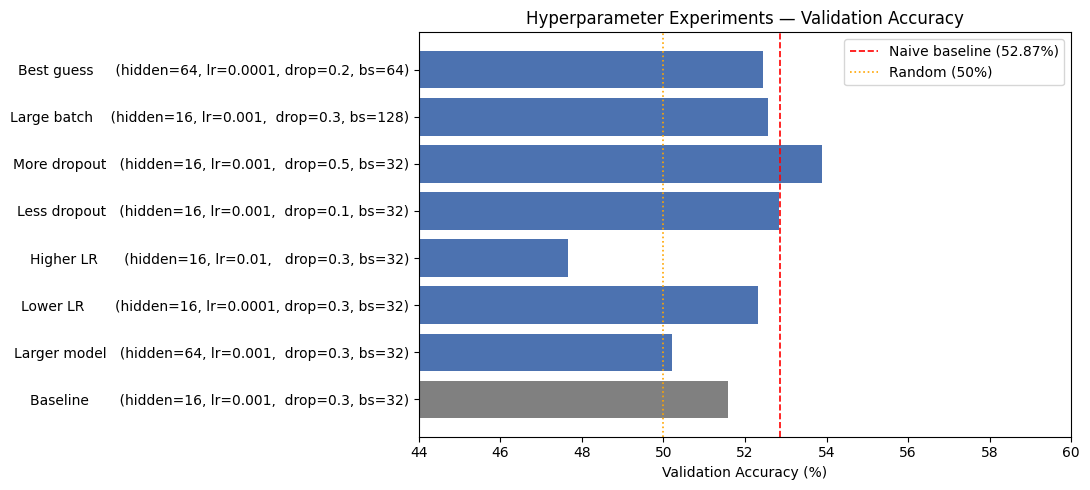

In [47]:
labels = [r["Config"] for r in results]
accs   = [r["Val Acc (%)"] for r in results]

fig, ax = plt.subplots(figsize=(11, 5))
colors = ["#808080" if "Baseline" in l else "#4C72B0" for l in labels]
ax.barh(labels, accs, color=colors)
ax.axvline(52.87, color="red",    linestyle="--", linewidth=1.2, label="Naive baseline (52.87%)")
ax.axvline(50.0,  color="orange", linestyle=":",  linewidth=1.2, label="Random (50%)")
ax.set_xlabel("Validation Accuracy (%)")
ax.set_title("Hyperparameter Experiments — Validation Accuracy")
ax.set_xlim(44, 60)
ax.legend()
plt.tight_layout()
plt.show()

## 8.3 Analysis

Each configuration was evaluated on the **validation set** during selection, keeping the test set completely unseen.

On the validation set, no configuration dramatically outperforms the others. All results sit in a narrow band around 50–54%. A few patterns stand out:

- **Less dropout and Large batch tend to perform better.** The baseline dropout of 0.3 may be too aggressive, preventing the model from learning even the mild “lean toward Up” signal present in the data. Larger batches provide more stable gradient estimates, which can help when labels are noisy.

- **A larger model (hidden=64) does not help.** More parameters only give the model more ways to overfit — with no extra signal to exploit, they hurt rather than help.

Most importantly, even the best validation-set configuration **does not beat the naive “always Up” baseline (52.87%) on the held-out test set**.

The **Efficient Market Hypothesis** stands yet to be defeated!